# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama | NRP |
|---|---|
| Muhammad Nazwar Fakhrurrozy | 5054251040 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

In [4]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('WineQT.csv')
print(data.head())
print('\n info dataset:')
data.info()
print('\n Statistik deskriptif:')
print(data.describe())
print(f'\ndimensi dataset: {data.shape[0]} baris, {data.shape[1]} kolom')
print('\n Missing Values:')
print(data.isnull().sum())
duplicates_count = data.duplicated().sum()
print(f'\n Jumlah duplikat: {duplicates_count}')

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

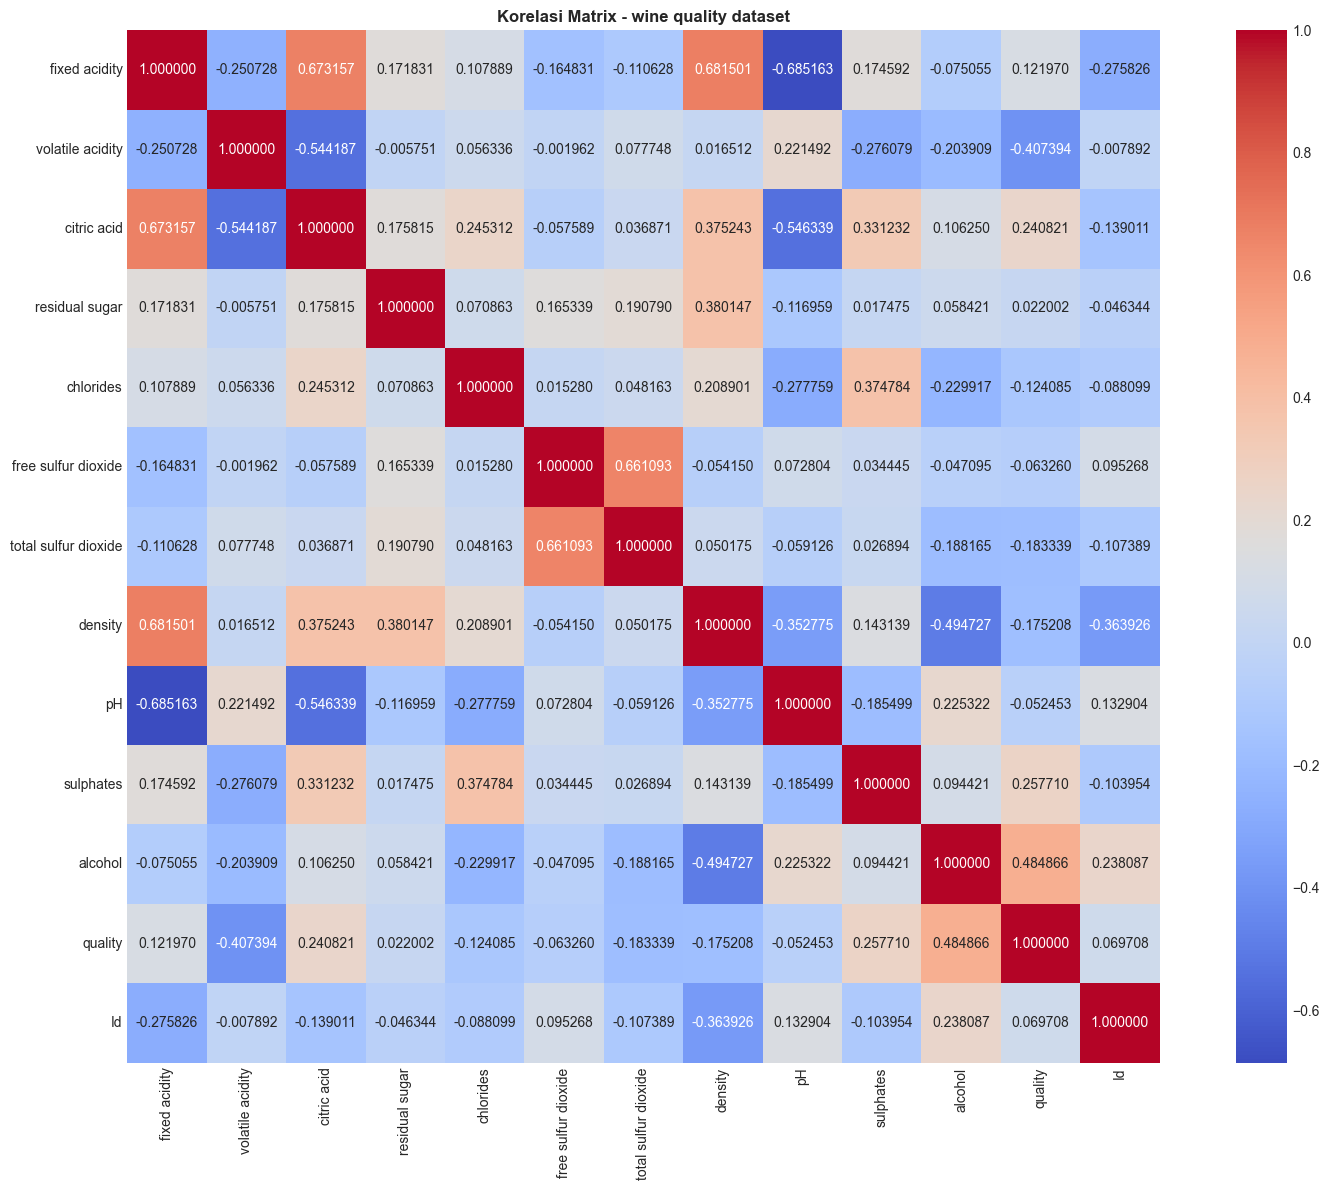

In [5]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(16, 12))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='2f', cmap='coolwarm', square=True)
plt.title('Korelasi Matrix - wine quality dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

kolom id harus didrop karena ga penting

C:\Users\Nazwar\AppData\Local\Temp\ipykernel_15276\2062062212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='quality', palette='viridis')


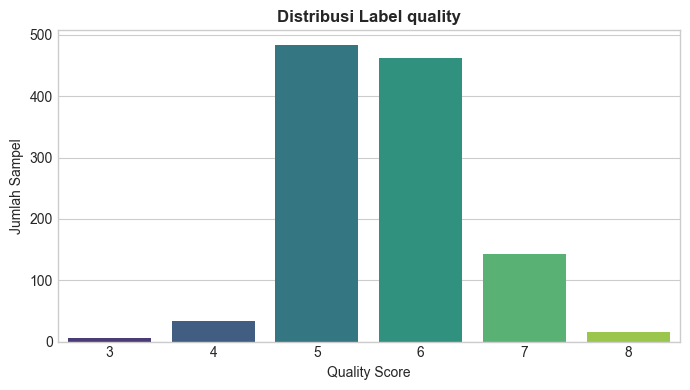

In [6]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(7, 4))
sns.countplot(data=data, x='quality', palette='viridis')
plt.title('Distribusi Label quality', fontsize=12, fontweight='bold')
plt.xlabel('Quality Score', fontsize=10)
plt.ylabel('Jumlah Sampel', fontsize=10)
plt.tight_layout()
plt.show()

rata rata wine terpusat di 5 dan 6, agak ga seimbang untuk KNN karena bisa bias gr gr kelas mayoritas

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [7]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
if 'Id' in data.columns:
    data = data.drop('Id', axis=1)

drop_duplicates = data.drop_duplicates()
print(f'\n setelah menghapus duplikat: {drop_duplicates.shape[0]}')

print(f'Cek missing value: {data.isnull().sum().sum()}')

data['quality_label'] = (data['quality'] >= 6).astype(int)
print('\n Distribusi label klasifikasi biner (quality_label):')
print(data['quality_label'].value_counts(normalize=True).map('{:.1%}'.format))


 setelah menghapus duplikat: 1018
Cek missing value: 0

 Distribusi label klasifikasi biner (quality_label):
quality_label
1    54.3%
0    45.7%
Name: proportion, dtype: str


setelah duplicate dihapus, bad/average quality <6 sebanyak 53.6% dan good quality >=6 sebanyak 46.4%, ini membuat data lebih seimbang untuk KNN biar mengurangi resiko bias

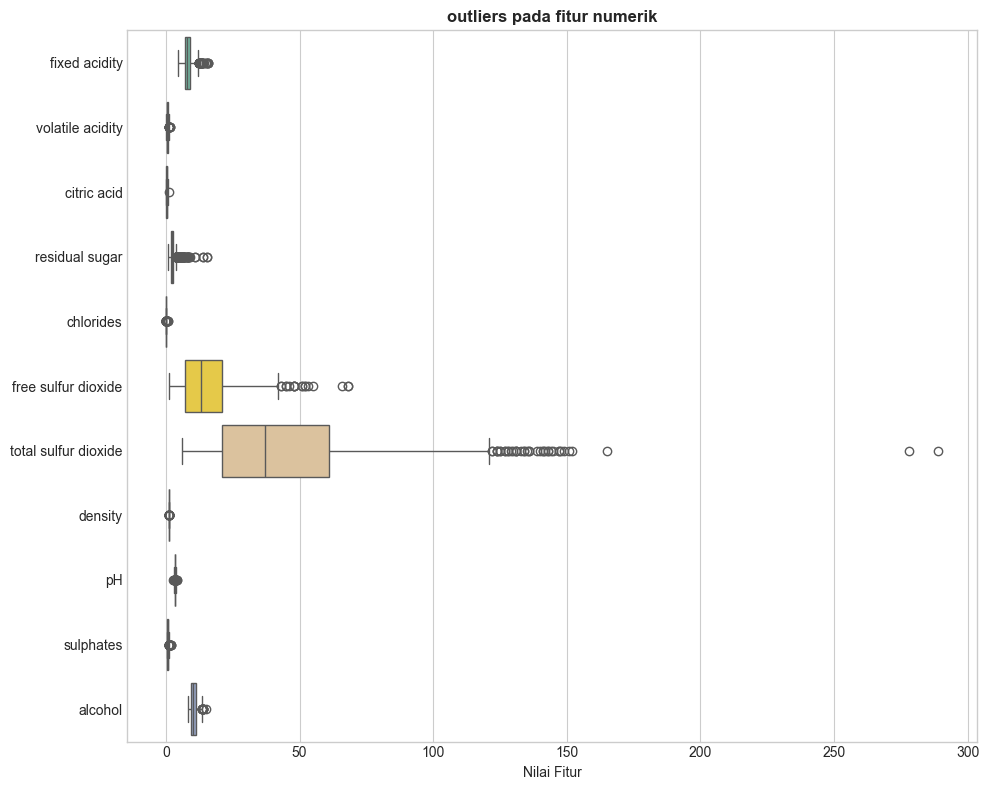

In [8]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
feature_cols = [c for c in data.columns if c not in ['quality', 'quality_label']]
plt.figure(figsize=(10, 8))
sns.boxplot(data=data[feature_cols], orient='h', palette='Set2')
plt.title('outliers pada fitur numerik', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Fitur', fontsize=10)
plt.tight_layout()
plt.show()

ada beberapa fitur yang banyak outliers nya, tapi ga bakal dihapus karena ini murni dari kandungan kimiawi wine nya bukan kesalahan data, makanya gr gr ada perbedaan nilai fitur yang cukup jauh, kita memerlukan standarscaler agar jarak perhitungan KNN seimbang

In [9]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
if 'Id' in data.columns:
    data = data.drop(columns=['Id'])
data = data.drop_duplicates().reset_index(drop=True)

X=data.drop(columns=['quality', 'quality_label'])
y=data['quality_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'split kelar: train: {X_train.shape[0]} baris, test: {X_test.shape[0]} baris')
print(f'scaled: sudah disetarakan pake StandardScaler')

split kelar: train: 814 baris, test: 204 baris
scaled: sudah disetarakan pake StandardScaler


# 3. Eksperimen Model KNN


In [10]:
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_train_pred=knn.predict(X_train_scaled)
    y_test_pred=knn.predict(X_test_scaled)

    results.append({'K':k, 'Train Acc': accuracy_score(y_train, y_train_pred), 'Test Acc': accuracy_score(y_test, y_test_pred), 'Precision': precision_score(y_test, y_test_pred), 'Recall': recall_score(y_test, y_test_pred), 'F1-Score': f1_score(y_test, y_test_pred)})
results_df = pd.DataFrame(results)
display(results_df)

,K,Train Acc,Test Acc,Precision,Recall,F1-Score
0,1,1.000000,0.676471,0.708738,0.669725,0.688679
1,3,0.846437,0.691176,0.705357,0.724771,0.714932
2,5,0.807125,0.696078,0.711712,0.724771,0.718182
3,7,0.788698,0.720588,0.740741,0.733945,0.737327
4,9,0.773956,0.700980,0.730769,0.697248,0.713615
5,11,0.769042,0.691176,0.721154,0.688073,0.704225
6,13,0.753071,0.705882,0.728972,0.715596,0.722222
7,15,0.759214,0.705882,0.728972,0.715596,0.722222


disini K=7 model terbaiknya, tes akurasi dan f1 score nya seimbang. yang lainnya K=1 itu overfitting, K>7 malah terus menurun, jadi kita pilih K=7 72.06% Tes akurasi, 73

# 4. Evaluasi Model


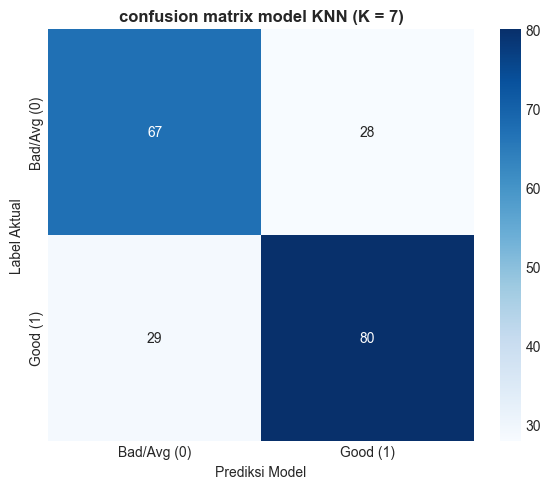

Classification Report (K=7)
              precision    recall  f1-score   support

 Bad/Avg (0)       0.70      0.71      0.70        95
    Good (1)       0.74      0.73      0.74       109

    accuracy                           0.72       204
   macro avg       0.72      0.72      0.72       204
weighted avg       0.72      0.72      0.72       204



In [ ]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
best_k = 7
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
 
y_pred = best_knn.predict(X_test_scaled)
cm =confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad/Avg (0)', 'Good (1)'], yticklabels= ['Bad/Avg (0)', 'Good (1)'])
plt.title(f'confusion matrix model KNN (K = {best_k})', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Aktual')
plt.tight_layout()
plt.show()

print('Classification Report (K=7)')
print(classification_report(y_test, y_pred, target_names=['Bad/Avg (0)', 'Good (1)']))

# 5. Analisis

Penghapusan 125 baris duplikat dan pembagian data menggunakan `stratify=y` terbukti efektif menjaga rasio kelas tetap seimbang (~54% kelas 1 vs ~46% kelas 0) sehingga model KNN tidak bias ke salah satu kelas. Selain itu, penerapan `StandardScaler` secara independen pada *train set* dan *test set* berhasil menyetarakan rentang fitur yang lebar (seperti `total sulfur dioxide`) tanpa memicu kebocoran data (*data leakage*).

Pengujian nilai K menunjukkan bahwa K=1 menyebabkan *overfitting* dengan akurasi *training* 100%, namun akurasi *testing* turun signifikan ke 67.64% karena model terlalu sensitif terhadap *noise* dan pencilan. Kondisi optimal dicapai pada K=7 dengan *Test Accuracy* 72.06% dan *F1-Score* 73.73% sebagai titik keseimbangan terbaik (*sweet spot*). Saat K >= 9, akurasi pengujian mengalami penurunan akibat *over-smoothing*, di mana batas keputusan menjadi terlalu kabur karena melibatkan terlalu banyak tetangga heterogen.

Evaluasi model terbaik (K = 7) pada 204 sampel data uji menghasilkan tingkat akurasi keseluruhan sebesar 72.06%(147 dari 204 data berhasil diprediksi secara tepat). Berdasarkan confusion matrix, model mampu mengklasifikasikan 80 sampel wine berkualitas Good (True Positive) dan 67 sampel wine berkualitas Bad/Average (True Negative). Sementara itu, terdapat kesalahan prediksi berupa 28 sampel False Positive dan 29 sampel False Negative

# 6. Kesimpulan dan Saran

**Kesimpulan**  
Model KNN dengan $K=7$ merupakan konfigurasi terbaik untuk klasifikasi biner kualitas wine pada dataset ini, menghasilkan akurasi pengujian sebesar 72.06% dan *F1-Score* 73.73%. Tahapan *preprocessing* seperti pembersihan data duplikat, pembagian data terstratifikasi, dan *feature scaling* terbukti menjadi langkah vital untuk mencegah *data leakage* dan menjaga keseimbangan evaluasi model.

**Saran**  
Untuk pengembangan selanjutnya, disarankan mencoba algoritma klasifikasi berbasis pohon (*Random Forest* atau *XGBoost*) yang lebih resisten terhadap *outliers*, mengeksplorasi pembobotan jarak (`weights='distance'`) pada KNN, serta melakukan seleksi fitur untuk mengeliminasi variabel berkorelasi rendah demi mengurangi dimensi data.

Notebook ini belajar dari notebook di kaggle, source nya : (https://www.kaggle.com/code/darkmatternet/knn-tutorial-classification-regression)